# GNN + LSTM PPO за CityLearn (Static Graph)

Овој бележник прикажува:
- **Околина & тренинг:** PPO агент со LSTM + GNN (GATv2) feature extractor во CityLearn 2022 Phase 1.
- **Статички граф:** меѓузградните релации се пресметуваат **еднаш** и се користат во текот на тренингот.
- **Евалуација низ време:** график на средна награда.
- **Генерализација:** евалуација на сите згради + табела со резултати.


In [1]:
%pip install -U --no-cache-dir pip setuptools wheel
%pip uninstall -y gym


%pip install --no-cache-dir "numpy==1.26.4" "scikit-learn==1.5.2" "pandas==2.2.2" "pyyaml==6.0.2"


%pip install --no-cache-dir "citylearn==2.3.0" --no-deps


%pip install --no-cache-dir "gymnasium==0.29.1" "stable-baselines3[extra]==2.2.1" \
  "doe-xstock==1.1.0" "nrel_pysam==7.1.0"



  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of shimmy[atari] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of shimmy[atari] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of stable-baselines3[extra] to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
ERROR: Cannot install stable-baselines3==2.2.1 and stable-baselines3[extra]==2.2.1 because these package versions have conflicting dependencies.

The confli

In [2]:
%pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cu121 \
  "torch==2.2.2" "torchvision==0.17.2" "torchaudio==2.2.2"


%pip install --no-cache-dir -f https://data.pyg.org/whl/torch-2.2.2+cu121.html \
  "pyg-lib==0.4.0" "torch-scatter==2.1.2" "torch-sparse==0.6.18" \
  "torch-cluster==1.6.3" "torch-spline-conv==1.2.2" "torch-geometric==2.5.3"


Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.2.2+cu121.html


In [3]:

%pip install --no-cache-dir "nrel_pysam==7.1.0"


import PySAM, sys
print("PySAM OK ->", PySAM.__file__)


PySAM OK -> /usr/local/lib/python3.12/dist-packages/PySAM/__init__.py


In [4]:

%pip uninstall -y stable-baselines3 shimmy AutoROM AutoROM.accept-rom-license ale-py


%pip install --no-cache-dir "stable-baselines3==2.2.1"


from stable_baselines3 import PPO
print("SB3 OK ✅")



Found existing installation: stable-baselines3 2.2.1
Uninstalling stable-baselines3-2.2.1:
  Successfully uninstalled stable-baselines3-2.2.1
SB3 OK ✅


## Околина и тренинг (кратко)
- **Околина:** `CityLearnEnv(schema="citylearn_challenge_2022_phase_1", central_agent=False)`.
- **Награда:** custom reward што минимизира трошок (−net_elec×price), поттикнува соларно и благо центрира SOC.
- **Архитектура:** *LSTM* над прозорец од 12 часа + *GNN (GATv2)* над **статички граф** (фиксен adjacency).
- **Фузија:** LSTM излез + GNN embedding на таргет зградата → збир/конкат како влез во акторот/критикот.
- **Тренирање:** PPO (SB3), `n_steps=1024`, `batch_size=64`, нормализирана предност, логирање во TensorBoard.

In [3]:
import os, json, time
import numpy as np
import torch, torch.nn as nn
from gymnasium import Env, spaces
from citylearn.citylearn import CityLearnEnv
from citylearn.reward_function import RewardFunction
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATv2Conv

print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda, "| CUDA available:", torch.cuda.is_available())


class CustomReward(RewardFunction):
    def __init__(self, env_metadata):
        super().__init__(env_metadata)
    def calculate(self, observations):
        rewards_per_building = []
        for o in observations:
            net_electricity_consumption = o.get('net_electricity_consumption', 0.0)
            solar_generation = o.get('solar_generation', 0.0)
            battery_soc = o.get('electrical_storage_soc', 0.5)
            electricity_price = o.get('electricity_pricing', 0.0)
            reward = -1.0 * net_electricity_consumption * electricity_price
            reward += 0.2 * solar_generation
            if net_electricity_consumption > 0 and battery_soc < 0.1:
                reward -= 0.5
            if battery_soc > 0.9 and net_electricity_consumption < 0.1 and solar_generation > 0.1:
                reward -= 0.3
            if electricity_price < 0.1 and o.get('charging_rate', 0.0) > 0:
                reward += 0.1
            if electricity_price > 0.5 and o.get('discharging_rate', 0.0) > 0:
                reward += 0.1
            reward -= 0.05 * abs(battery_soc - 0.5)
            rewards_per_building.append(np.clip(reward, -20.0, 20.0))
        return rewards_per_building


def build_dynamic_graph_CORR_MUTUAL(env, k=2, hist=24):
    import numpy as np, torch
    def tail_pad(xs, T):
        xs = np.array(xs, dtype=float)
        if xs.size == 0: return np.zeros(T, dtype=float)
        if xs.size >= T: return xs[-T:]
        return np.concatenate([xs, np.full(T - xs.size, xs[-1], dtype=float)])
    n = len(env.buildings)
    nets, sols, socs = [], [], []
    for b in env.buildings:
        nets.append(tail_pad(b.net_electricity_consumption, hist))
        sols.append(tail_pad(b.solar_generation, hist))
        socs.append(tail_pad(b.electrical_storage.soc, hist))
    X = np.concatenate([np.stack(nets,0), np.stack(sols,0), np.stack(socs,0)], axis=1)
    X = StandardScaler().fit_transform(X)
    C = np.corrcoef(X)
    S = np.clip(C, 0.0, 1.0)
    knn = []
    for i in range(n):
        order = np.argsort(-S[i])
        neigh = [j for j in order if j != i][:k]
        knn.append(neigh)
    def mutual(i, j): return (i in knn[j]) and (j in knn[i])
    edge_index, edge_attr = [], []
    for i in range(n):
        for j in knn[i]:
            if mutual(i, j):
                w = float(S[i, j])
                edge_index += [[i, j], [j, i]]
                edge_attr  += [[w], [w]]
    feats = []
    for i in range(n):
        feats.append([float(np.mean(nets[i])), float(np.mean(sols[i])), float(np.mean(socs[i]))])
    feats = torch.tensor(np.array(feats), dtype=torch.float32)
    edge_index = torch.tensor(edge_index).T.long() if len(edge_index) else torch.empty((2,0), dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr).float()   if len(edge_attr)  else torch.empty((0,1), dtype=torch.float32)
    return feats, edge_index, edge_attr


class CityLearnSingleBuildingWrapper(Env):
    def __init__(self, env, building_id=0, seq_len=12):
        super().__init__()
        self.env = env
        self.building_id = building_id
        self.seq_len = seq_len
        self.n_buildings = len(env.action_space)
        self.obs_dim = env.observation_space[building_id].shape[0]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(seq_len*self.obs_dim,), dtype=np.float32)
        self.buf = []
    def reset(self, **kwargs):
        obs, _ = self.env.reset(**kwargs)
        self.buf = []
        o = obs[self.building_id]
        for _ in range(self.seq_len): self.buf.append(o)
        return np.concatenate(self.buf), {}
    def step(self, action):
        actions = [[0.0]*self.env.action_space[0].shape[0] for _ in range(self.n_buildings)]
        actions[self.building_id] = [float(action[0])]
        obs, reward, terminated, truncated, info = self.env.step(actions)
        o = obs[self.building_id]
        self.buf.pop(0); self.buf.append(o)
        return np.concatenate(self.buf), reward[self.building_id], terminated, truncated, info

# --- 5) Feature extractor (GNN + LSTM) ---
class GNN_LSTM_FeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, env, hidden_size=64, lstm_layers=1):
        super().__init__(observation_space, features_dim=hidden_size)
        self.hidden_size = hidden_size
        self.obs_dim = observation_space.shape[0] // 12
        self.lstm = nn.LSTM(self.obs_dim, hidden_size, lstm_layers, batch_first=True)
        self.hidden = None
        self.env = env
        self.building_id = getattr(env, 'building_id', 0)
        in_feats = 3
        self.graph_x = torch.zeros((len(env.buildings), in_feats), dtype=torch.float32)
        self.edge_index = torch.empty((2,0), dtype=torch.long)
        self.edge_attr  = torch.empty((0,1), dtype=torch.float32)
        self.gnn1 = GATv2Conv(in_feats, hidden_size, edge_dim=1)
        self.gnn2 = GATv2Conv(hidden_size, hidden_size, edge_dim=1)
    def update_graph(self):
        gx, ei, ea = build_dynamic_graph_CORR_MUTUAL(self.env, k=2, hist=24)
        self.graph_x, self.edge_index, self.edge_attr = gx, ei, ea
    def forward(self, obs):
        b = obs.shape[0]
        x = obs.view(b, 12, self.obs_dim).float()
        if self.hidden is None or self.hidden[0].shape[1] != b:
            h0 = torch.zeros(self.lstm.num_layers, b, self.hidden_size, device=x.device)
            c0 = torch.zeros(self.lstm.num_layers, b, self.hidden_size, device=x.device)
            self.hidden = (h0, c0)
        out, self.hidden = self.lstm(x, self.hidden)
        self.hidden = (self.hidden[0].detach(), self.hidden[1].detach())
        lstm_feat = out[:, -1, :]
        if self.edge_index.numel() == 0:
            gnn_feat = torch.zeros((b, self.hidden_size), device=x.device)
        else:
            gx = torch.relu(self.gnn1(self.graph_x.to(x.device), self.edge_index.to(x.device), self.edge_attr.to(x.device)))
            gx = torch.relu(self.gnn2(gx, self.edge_index.to(x.device), self.edge_attr.to(x.device)))
            gnn_feat = gx[self.building_id].unsqueeze(0).expand(b, -1)
        return lstm_feat + gnn_feat

class CustomGNNLSTMPolicy(ActorCriticPolicy):
    def __init__(self, observation_space, action_space, lr_schedule, env, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule,
                         features_extractor_class=GNN_LSTM_FeatureExtractor,
                         features_extractor_kwargs={"env": env},
                         **kwargs)

if __name__ == "__main__":

    base_env = CityLearnEnv(schema='citylearn_challenge_2022_phase_1',
                            reward_function=CustomReward,
                            central_agent=False)
    single_env = CityLearnSingleBuildingWrapper(base_env, building_id=0, seq_len=12)


    os.makedirs("./logs/train", exist_ok=True)
    def make_train_env():

        env_ = CityLearnSingleBuildingWrapper(base_env, building_id=0, seq_len=12)
        return Monitor(env_, filename="./logs/train/monitor")

    vec_env = DummyVecEnv([make_train_env])

    # === Модел ===
    model = PPO(
        CustomGNNLSTMPolicy,
        vec_env,
        device="cuda" if torch.cuda.is_available() else "cpu",
        normalize_advantage=True,
        verbose=1,
        n_steps=1024,
        batch_size=64,
        learning_rate=3e-4,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,
        vf_coef=0.4,
        max_grad_norm=0.5,
        policy_kwargs={"env": base_env},
        seed=0
    )


    model.policy.features_extractor.update_graph()

    eval_base_env = CityLearnEnv(schema='citylearn_challenge_2022_phase_1',
                                 reward_function=CustomReward,
                                 central_agent=False)
    def make_eval_env():
        env_eval = CityLearnSingleBuildingWrapper(eval_base_env, building_id=0, seq_len=12)
        return Monitor(env_eval, filename="./logs/eval/monitor")
    eval_vec = DummyVecEnv([make_eval_env])


    os.makedirs("./logs/best_model", exist_ok=True)
    os.makedirs("./logs/eval", exist_ok=True)
    eval_cb = EvalCallback(
        eval_vec,
        best_model_save_path="./logs/best_model",
        log_path="./logs/eval",
        eval_freq=10_000,
        deterministic=True,
        render=False,
        n_eval_episodes=1
    )

    # === Train + Eval ===
    model.learn(total_timesteps=500_000, callback=eval_cb)
    model.save("ppo_gnn_lstm_corr_mutual_static_500k")
    print(" Saved final: ppo_gnn_lstm_corr_mutual_static_500k.zip")
    print(" Best model (by eval): ./logs/best_model/best_model.zip")
    print(" Logs:")
    print("   - Train monitor: ./logs/train/monitor*.csv")
    print("   - Eval monitor:  ./logs/eval/monitor*.csv")


Streaming output truncated to the last 5000 lines.
|    clip_range           | 0.2         |
|    entropy_loss         | -1.36       |
|    explained_variance   | 0.662       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.12        |
|    n_updates            | 2710        |
|    policy_gradient_loss | -0.00156    |
|    std                  | 0.94        |
|    value_loss           | 4.53        |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 8.76e+03    |
|    ep_rew_mean          | -683        |
| time/                   |             |
|    fps                  | 43          |
|    iterations           | 273         |
|    time_elapsed         | 6354        |
|    total_timesteps      | 279552      |
| train/                  |             |
|    approx_kl            | 0.029894184 |
|    clip_fraction        | 0.23        |
|    clip_range          

## Читање на тренинг логови
- **total_timesteps / iterations:** прогрес на тренингот.
- **approx_kl, clip_fraction:** стабилност на PPO апдејтот; нормално е да се движат ниско/умерено.
- **entropy_loss, std:** ниво на истражување; постепено опаѓање на ентропија е очекувано.
- **explained_variance:** колку добро value мрежата ги објаснува враќањата (повисоко е подобро).
- **value_loss / loss:** следи стабилност; умерени осцилации се во ред.
За подетално следење користи и **TensorBoard** логовите.


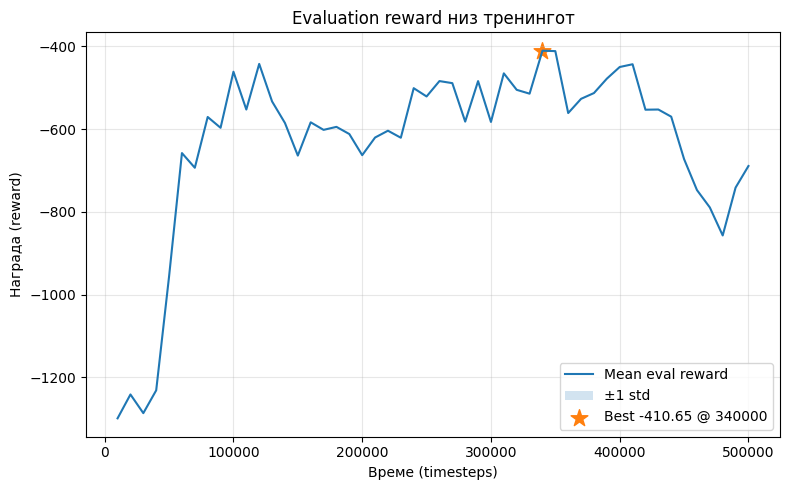

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

eval_path = Path("evaluations_StaticGraph.npz")

with np.load(eval_path) as data:
    timesteps = data["timesteps"]
    results = data["results"]

mean_reward = results.mean(axis=1)
std_reward = results.std(axis=1)
best_idx = int(np.argmax(mean_reward))

plt.figure(figsize=(8,5))
plt.plot(timesteps, mean_reward, label="Mean eval reward")
plt.fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward, alpha=0.2, label="±1 std")
plt.scatter([timesteps[best_idx]], [mean_reward[best_idx]], marker="*", s=160,
            label=f"Best {mean_reward[best_idx]:.2f} @ {int(timesteps[best_idx])}")

plt.xlabel("Време (timesteps)")
plt.ylabel("Награда (reward)")
plt.title("Evaluation reward низ тренингот")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## График: евалуациска награда низ време
- Податоците доаѓаат од `EvalCallback` (`./logs/eval/evaluations_StaticGraph.npz`).
- Прикажи **mean eval reward** vs. `timesteps` (+ опц. moving average за помазна крива).
- „Најдобра точка“ ↔ највисока средна награда; соодветниот модел е снимен во `./logs/best_model_StaticGraph/`.


In [3]:

%pip uninstall -y stable-baselines3 shimmy AutoROM AutoROM.accept-rom-license ale-py

%pip install --no-cache-dir "stable-baselines3==2.2.1"


from stable_baselines3 import PPO
print("SB3 OK ✅")

Found existing installation: ale-py 0.11.2
Uninstalling ale-py-0.11.2:
  Successfully uninstalled ale-py-0.11.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.7/181.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 38.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.0
    Uninstalling gymnasium-1.2.0:
      Successfully uninstalled gymnasium-1.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires ale-py>=0.10.1, which is not installed.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
SB3 OK ✅


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
!pip -q install "scikit-learn==1.2.2" > /dev/null

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
citylearn 2.3.0 requires doe-xstock>=1.1.0, which is not installed.
citylearn 2.3.0 requires openstudio<=3.3.0, which is not installed.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
imbalanced-learn 0.14.0 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.2.2 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.2.2 which is incompatible.


In [5]:
from citylearn.reward_function import RewardFunction

class CustomReward(RewardFunction):
    def __init__(self, env_metadata):
        super().__init__(env_metadata)
    def calculate(self, observations):
        rewards_per_building = []
        for o in observations:
            net_electricity_consumption = o.get('net_electricity_consumption', 0.0)
            solar_generation = o.get('solar_generation', 0.0)
            battery_soc = o.get('electrical_storage_soc', 0.5)
            electricity_price = o.get('electricity_pricing', 0.0)
            reward = -1.0 * net_electricity_consumption * electricity_price
            reward += 0.2 * solar_generation
            if net_electricity_consumption > 0 and battery_soc < 0.1:
                reward -= 0.5
            if battery_soc > 0.9 and net_electricity_consumption < 0.1 and solar_generation > 0.1:
                reward -= 0.3
            if electricity_price < 0.1 and o.get('charging_rate', 0.0) > 0:
                reward += 0.1
            if electricity_price > 0.5 and o.get('discharging_rate', 0.0) > 0:
                reward += 0.1
            reward -= 0.05 * abs(battery_soc - 0.5)
            rewards_per_building.append(np.clip(reward, -20.0, 20.0))
        return rewards_per_building

In [10]:
from gymnasium import Env, spaces
from citylearn.citylearn import CityLearnEnv

In [11]:
class CityLearnSingleBuildingWrapper(Env):
    def __init__(self, env, building_id=0, seq_len=12):
        super().__init__()
        self.env = env
        self.building_id = building_id
        self.seq_len = seq_len
        self.n_buildings = len(env.action_space)
        self.obs_dim = env.observation_space[building_id].shape[0]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(seq_len*self.obs_dim,), dtype=np.float32)
        self.buf = []
    def reset(self, **kwargs):
        obs, _ = self.env.reset(**kwargs)
        self.buf = []
        o = obs[self.building_id]
        for _ in range(self.seq_len): self.buf.append(o)
        return np.concatenate(self.buf), {}
    def step(self, action):
        actions = [[0.0]*self.env.action_space[0].shape[0] for _ in range(self.n_buildings)]
        actions[self.building_id] = [float(action[0])]
        obs, reward, terminated, truncated, info = self.env.step(actions)
        o = obs[self.building_id]
        self.buf.pop(0); self.buf.append(o)
        return np.concatenate(self.buf), reward[self.building_id], terminated, truncated, info

In [12]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 3
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("best_model_StaticGraph.zip")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

📊 Total reward on unseen building 3: -712.01


In [13]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 1
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("best_model_StaticGraph.zip")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

📊 Total reward on unseen building 1: -710.01


In [14]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 2
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("best_model_StaticGraph.zip")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

📊 Total reward on unseen building 2: 174.08


In [15]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 4
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("best_model_StaticGraph.zip")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

📊 Total reward on unseen building 4: -254.11


## Генерализација на невидени згради (Static Graph, deterministic eval)

Овие резултати се добиени со следниот евалуациски код (детерминистичка политика, без шум):

- `PPO.load("best_model_StaticGraph.zip")`
- `CityLearnSingleBuildingWrapper(..., building_id=<ID>, seq_len=12)`
- Loop до крај на епизодата (една година ≈ 8759 чекори), се сумира **Total reward**
- Се користи **истиот `CustomReward`** како на тренинг  
- **Поголема (помалку негативна/позитивна) `Total reward` = подобро**

Забелешка: Ова е **сумарна** награда за цела епизода, па не е исто што и тренинг „per-step“ логови. Вредностите служат за споредба на **генерализацијата** меѓу различни згради.


### Резултати по зграда

| Зграда (ID) | Total reward | Ранг |
|---:|---:|---:|
| 2 | **+174.08** | 🥇 1 |
| 4 | −254.11 | 🥈 2 |
| 1 | −710.01 | 🥉 3 |
| 3 | −712.01 | 4 |

**Толкување:**  
- Најдобра генерализација: **зграда 2** (позитивна вкупна награда).  
- Умерено: **зграда 4** (блиску до нула, релативно подобро од 1 и 3).  
- Послабо: **згради 1 и 3** (повеќе негативна сумарна награда).


